<a href="https://colab.research.google.com/github/hy961/mimiciv-hansen/blob/main/mimic_iv_hansen_explore_mimiciv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIMIC-IV Demo — Procedures & Input/Output Events (Colab version)

**Owner:** Hansen · Interim environment while the Databricks/S3 setup is finalised.

This notebook covers my whole domain end to end: exploration, cleaning, and two analysis-ready outputs.
The same logic will move to Databricks (PySpark + Delta) once the platform is ready.


## 0. Get the data (downloads straight from PhysioNet, no manual upload needed)


In [1]:
!wget -q https://physionet.org/static/published-projects/mimic-iv-demo/mimic-iv-clinical-database-demo-2.2.zip
!unzip -q -o mimic-iv-clinical-database-demo-2.2.zip
BASE = "mimic-iv-clinical-database-demo-2.2"
!ls {BASE}


demo_subject_id.csv  hosp  icu	LICENSE.txt  README.txt  SHA256SUMS.txt


## 1. Load my six tables

Key detail: `icd_code` is forced to **string**. About a third of the codes start with 0
(like `0066`), and letting pandas guess the type turns them into integers and corrupts joins.


In [2]:
import pandas as pd
import numpy as np

pi = pd.read_csv(f"{BASE}/hosp/procedures_icd.csv.gz", dtype={"icd_code": str})
dp = pd.read_csv(f"{BASE}/hosp/d_icd_procedures.csv.gz", dtype={"icd_code": str})
pe = pd.read_csv(f"{BASE}/icu/procedureevents.csv.gz")
ie = pd.read_csv(f"{BASE}/icu/inputevents.csv.gz")
ig = pd.read_csv(f"{BASE}/icu/ingredientevents.csv.gz")
oe = pd.read_csv(f"{BASE}/icu/outputevents.csv.gz")

tables = {"procedures_icd": pi, "d_icd_procedures": dp, "procedureevents": pe,
          "inputevents": ie, "ingredientevents": ig, "outputevents": oe}
for name, df in tables.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} cols")


procedures_icd: 722 rows x 6 cols
d_icd_procedures: 85,257 rows x 3 cols
procedureevents: 1,468 rows x 22 cols
inputevents: 20,404 rows x 26 cols
ingredientevents: 25,728 rows x 17 cols
outputevents: 9,362 rows x 9 cols


## 2. Quick profile of every table


In [3]:
for name, df in tables.items():
    print("="*70)
    print(name, df.shape)
    print(df.dtypes.to_string())
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print("nulls:")
        for c, v in nulls.items():
            print(f"  {c}: {v:,} ({v/len(df)*100:.1f}%)")
    print("duplicate rows:", df.duplicated().sum())


procedures_icd (722, 6)
subject_id      int64
hadm_id         int64
seq_num         int64
chartdate      object
icd_code       object
icd_version     int64
duplicate rows: 0
d_icd_procedures (85257, 3)
icd_code       object
icd_version     int64
long_title     object
duplicate rows: 0
procedureevents (1468, 22)
subject_id                    int64
hadm_id                       int64
stay_id                       int64
caregiver_id                float64
starttime                    object
endtime                      object
storetime                    object
itemid                        int64
value                       float64
valueuom                     object
location                     object
locationcategory             object
orderid                       int64
linkorderid                   int64
ordercategoryname            object
ordercategorydescription     object
patientweight               float64
isopenbag                     int64
continueinnextdept            int64
sta

## 3. procedures_icd: the dual ICD-9 / ICD-10 problem

MIMIC-IV mixes two coding systems. Some codes exist in BOTH with different meanings,
so every dictionary join must use the pair `(icd_code, icd_version)`, never the code alone.


In [4]:
print("icd_version mix:")
print(pi["icd_version"].value_counts())

lz = pi[pi["icd_code"].str.startswith("0")]
print(f"\ncodes with leading zeros: {len(lz)} of {len(pi)} ({len(lz)/len(pi)*100:.0f}%)")

# codes present in BOTH versions of the dictionary
both = dp.groupby("icd_code")["icd_version"].nunique()
both = both[both > 1]
print(f"\ncodes existing in both ICD-9 and ICD-10: {len(both)}")
dp[dp["icd_code"].isin(both.index)].sort_values(["icd_code","icd_version"]).head(8)


icd_version mix:
icd_version
9     401
10    321
Name: count, dtype: int64

codes with leading zeros: 247 of 722 (34%)

codes existing in both ICD-9 and ICD-10: 6


,icd_code,icd_version,long_title
3826,031,9,Division of intraspinal nerve root
47861,031,10,"Upper Arteries, Bypass"
1731,045,9,Cranial or peripheral nerve graft
57831,045,10,"Lower Arteries, Destruction"
996,059,9,Other operations on nervous system
13937,059,10,"Upper Veins, Drainage"
997,067,9,Excision of thyroglossal duct or tract
64433,067,10,"Lower Veins, Dilation"


In [5]:
# join coverage with the correct composite key
merged = pi.merge(dp, on=["icd_code", "icd_version"], how="left", indicator=True)
print("rows without a dictionary match:", (merged["_merge"] == "left_only").sum(), "(expect 0)")


rows without a dictionary match: 0 (expect 0)


## 4. procedureevents: statuses and a schema quirk


In [6]:
print(pe["statusdescription"].value_counts())

upper = [c for c in pe.columns if c != c.lower()]
print("\nuppercase column names (only ones in the whole domain):", upper)

st, en = pd.to_datetime(pe["starttime"]), pd.to_datetime(pe["endtime"])
print("endtime < starttime rows:", (en < st).sum(), "(expect 0)")


statusdescription
FinishedRunning    1441
Stopped              26
Paused                1
Name: count, dtype: int64

uppercase column names (only ones in the whole domain): ['ORIGINALAMOUNT', 'ORIGINALRATE']
endtime < starttime rows: 0 (expect 0)


## 5. inputevents: the unified table (no more CareVue/MetaVision split)


In [7]:
print(ie["statusdescription"].value_counts())
print()
print("negative amounts:", (ie["amount"] < 0).sum())
print("zero amounts:", (ie["amount"] == 0).sum())
st, en = pd.to_datetime(ie["starttime"]), pd.to_datetime(ie["endtime"])
print("endtime < starttime:", (en < st).sum())

print()
print("unit variants (note mEq vs mEq.):")
print(ie["amountuom"].value_counts().head(10))


statusdescription
FinishedRunning    13080
ChangeDose/Rate     5543
Stopped              982
Paused               787
Bolus                 12
Name: count, dtype: int64

negative amounts: 0
zero amounts: 31
endtime < starttime: 0

unit variants (note mEq vs mEq.):
amountuom
ml       10676
mg        4907
dose      1868
units     1120
mcg        822
grams      433
mEq        412
mEq.       105
mmol        61
Name: count, dtype: int64


## 6. ingredientevents: new in MIMIC-IV, child of inputevents


In [8]:
linked = ig["orderid"].isin(set(ie["orderid"])).mean()
print(f"ingredient orders linking back to inputevents: {linked*100:.1f}%  (expect 100%)")


ingredient orders linking back to inputevents: 100.0%  (expect 100%)


## 7. outputevents: units and value ranges


In [9]:
print(oe["valueuom"].value_counts())   # MIMIC-III had ml vs mL chaos, should be uniform now
print()
print(oe["value"].describe(percentiles=[0.5, 0.99]))
print("zero-value rows:", (oe["value"] == 0).sum())


valueuom
ml    9362
Name: count, dtype: int64

count    9362.000000
mean      140.916150
std       287.222927
min         0.000000
50%        75.000000
99%      1000.000000
max      8000.000000
Name: value, dtype: float64
zero-value rows: 320


## 8. Cross-table checks: coverage and orphan keys


In [10]:
pat = pd.read_csv(f"{BASE}/hosp/patients.csv.gz")
adm = pd.read_csv(f"{BASE}/hosp/admissions.csv.gz")
icu = pd.read_csv(f"{BASE}/icu/icustays.csv.gz")

subj = set(pat["subject_id"])
print("patients in demo:", len(subj))
for name, df in tables.items():
    if "subject_id" in df.columns:
        cov = df["subject_id"].nunique()
        orphans = (~df["subject_id"].isin(subj)).sum()
        print(f"{name}: covers {cov} patients | orphan subject_ids: {orphans}")

# timestamps are future-shifted for de-identification (2110-2201): expected, do NOT 'clean' them
for name, col in [("inputevents","starttime"), ("outputevents","charttime"), ("procedureevents","starttime")]:
    ts = pd.to_datetime(tables[name][col])
    print(f"{name}.{col}: {ts.min()} -> {ts.max()}")


patients in demo: 100
procedures_icd: covers 92 patients | orphan subject_ids: 0
procedureevents: covers 100 patients | orphan subject_ids: 0
inputevents: covers 99 patients | orphan subject_ids: 0
ingredientevents: covers 99 patients | orphan subject_ids: 0
outputevents: covers 100 patients | orphan subject_ids: 0
inputevents.starttime: 2110-04-11 15:55:00 -> 2201-12-13 16:51:00
outputevents.charttime: 2110-04-11 17:00:00 -> 2201-12-13 18:00:00
procedureevents.starttime: 2110-04-11 16:02:00 -> 2201-12-12 14:00:00


## 9. Silver-style cleaning

Every fix here traces back to a finding above:
lowercase columns, proper types, mEq. merged into mEq, duration for interval tables,
zero rows flagged instead of dropped, and a readable version of ICD-9 codes.


In [11]:
import os
os.makedirs("silver", exist_ok=True)

def clean_common(df):
    df = df.rename(columns={c: c.lower() for c in df.columns})
    return df

# procedures_icd
pi_s = clean_common(pi.copy())
pi_s["chartdate"] = pd.to_datetime(pi_s["chartdate"])
pi_s["icd_code_display"] = np.where(
    (pi_s["icd_version"] == 9) & (pi_s["icd_code"].str.len() > 2),
    pi_s["icd_code"].str[:2] + "." + pi_s["icd_code"].str[2:],
    pi_s["icd_code"])

# procedureevents
pe_s = clean_common(pe.copy())   # this lowercases ORIGINALAMOUNT / ORIGINALRATE
for c in ["starttime", "endtime"]:
    pe_s[c] = pd.to_datetime(pe_s[c])
pe_s["duration_minutes"] = (pe_s["endtime"] - pe_s["starttime"]).dt.total_seconds().div(60).round(1)

# inputevents
ie_s = clean_common(ie.copy())
ie_s["amountuom"] = ie_s["amountuom"].replace({"mEq.": "mEq"})
for c in ["starttime", "endtime"]:
    ie_s[c] = pd.to_datetime(ie_s[c])
ie_s["duration_minutes"] = (ie_s["endtime"] - ie_s["starttime"]).dt.total_seconds().div(60).round(1)
ie_s["is_zero_amount"] = ie_s["amount"] == 0

# ingredientevents
ig_s = clean_common(ig.copy())
for c in ["starttime", "endtime"]:
    ig_s[c] = pd.to_datetime(ig_s[c])
ig_s["is_zero_amount"] = ig_s["amount"] == 0

# outputevents
oe_s = clean_common(oe.copy())
oe_s["charttime"] = pd.to_datetime(oe_s["charttime"])
oe_s["is_zero_value"] = oe_s["value"] == 0

dp_s = clean_common(dp.copy())

silver = {"procedures_icd": pi_s, "d_icd_procedures": dp_s, "procedureevents": pe_s,
          "inputevents": ie_s, "ingredientevents": ig_s, "outputevents": oe_s}
for name, df in silver.items():
    df.to_parquet(f"silver/{name}.parquet", index=False)

# data quality metrics: nothing is dropped in this domain, we flag instead of filter
dq = pd.DataFrame([(n, len(tables[n]), len(silver[n])) for n in silver],
                  columns=["table", "raw_rows", "silver_rows"])
dq["retained_pct"] = (dq["silver_rows"] / dq["raw_rows"] * 100).round(2)
print(dq.to_string(index=False))
print()
print("mEq merge check:", ie_s[ie_s['amountuom'].str.startswith('mEq', na=False)]['amountuom'].value_counts().to_dict())


           table  raw_rows  silver_rows  retained_pct
  procedures_icd       722          722         100.0
d_icd_procedures     85257        85257         100.0
 procedureevents      1468         1468         100.0
     inputevents     20404        20404         100.0
ingredientevents     25728        25728         100.0
    outputevents      9362         9362         100.0

mEq merge check: {'mEq': 517}


## 10. Gold outputs from my domain

1. `fact_procedures`: every coded procedure with its readable title (composite-key join)
2. `fluid_balance_daily`: daily intake vs output per ICU stay, a classic ICU metric


In [12]:
os.makedirs("gold", exist_ok=True)

fact = pi_s.merge(dp_s, on=["icd_code", "icd_version"], how="left")
fact = fact[["subject_id","hadm_id","seq_num","chartdate",
             "icd_code","icd_code_display","icd_version","long_title"]]
fact.to_parquet("gold/fact_procedures.parquet", index=False)

print("top 10 procedures in the demo cohort:")
print(fact["long_title"].value_counts().head(10).to_string())


top 10 procedures in the demo cohort:
long_title
Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach               23
Central venous catheter placement with guidance                                           22
Enteral infusion of concentrated nutritional substances                                   18
Continuous invasive mechanical ventilation for less than 96 consecutive hours             15
Venous catheterization, not elsewhere classified                                          13
Extracorporeal circulation auxiliary to open heart surgery                                13
Percutaneous abdominal drainage                                                           12
Insertion of endotracheal tube                                                            11
Introduction of Nutritional Substance into Upper GI, Via Natural or Artificial Opening    10
Arterial catheterization                                                                  10


In [13]:
intake = (ie_s[ie_s["amountuom"] == "ml"]
          .assign(day=lambda d: d["starttime"].dt.date)
          .groupby(["stay_id", "day"], as_index=False)["amount"].sum()
          .rename(columns={"amount": "intake_ml"}))

output = (oe_s.assign(day=lambda d: d["charttime"].dt.date)
          .groupby(["stay_id", "day"], as_index=False)["value"].sum()
          .rename(columns={"value": "output_ml"}))

balance = intake.merge(output, on=["stay_id", "day"], how="outer").fillna(0)
balance["net_balance_ml"] = (balance["intake_ml"] - balance["output_ml"]).round(1)
balance.to_parquet("gold/fluid_balance_daily.parquet", index=False)

balance.sort_values(["stay_id", "day"]).head(10)


,stay_id,day,intake_ml,output_ml,net_balance_ml
0,30057454,2171-11-14,1122.833338,1510.0,-387.2
1,30057454,2171-11-15,970.440446,1876.0,-905.6
2,30057454,2171-11-16,2040.110700,2700.0,-659.9
3,30057454,2171-11-17,1933.790014,2611.0,-677.2
4,30057454,2171-11-18,711.939650,3105.0,-2393.1
5,30101877,2143-03-22,1618.333310,2732.0,-1113.7
6,30101877,2143-03-23,0.000000,852.0,-852.0
7,30101877,2143-03-24,0.000000,1005.0,-1005.0
8,30101877,2143-03-25,0.000000,480.0,-480.0
9,30425410,2178-07-22,1213.862258,800.0,413.9


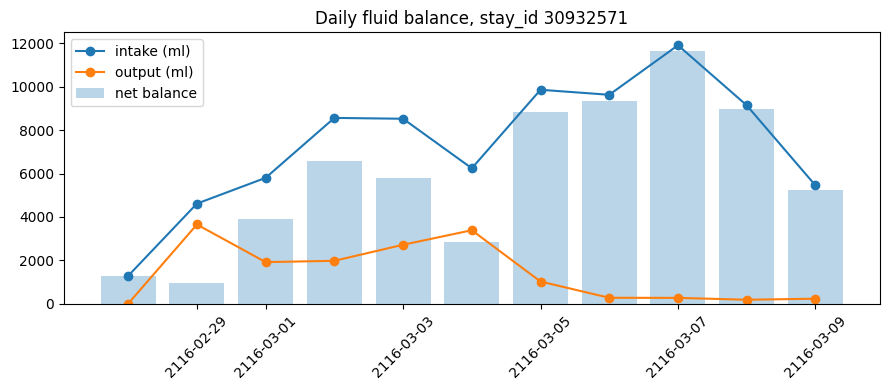

In [14]:
# quick visual: fluid balance over time for one stay (nice for the discussion)
import matplotlib.pyplot as plt

top_stay = balance.groupby("stay_id")["intake_ml"].sum().idxmax()
b = balance[balance["stay_id"] == top_stay].sort_values("day")

plt.figure(figsize=(9, 4))
plt.plot(b["day"], b["intake_ml"], marker="o", label="intake (ml)")
plt.plot(b["day"], b["output_ml"], marker="o", label="output (ml)")
plt.bar(b["day"], b["net_balance_ml"], alpha=0.3, label="net balance")
plt.title(f"Daily fluid balance, stay_id {top_stay}")
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 11. Summary

**Issues found and handled:** icd_code kept as string (leading zeros), composite (code, version)
join enforced, uppercase columns lowercased, mEq. merged into mEq, zero rows flagged not dropped,
future-shifted timestamps documented as expected.

**Next step:** rerun this exact logic in Databricks (PySpark notebooks 02-04) once the
mimic-iv S3 bucket and external location are ready. No rows dropped, so data retention is 100%.
